# fAIr predict ; minimal examples

Uses knative cold start for containers ; POST a bbox + tile URL + ONNX URI to a fAIr predict endpoint, render the returned GeoJSON.

```
uv run --with httpx --with geopandas --with matplotlib --with jupyter jupyter lab
```

In [36]:
import geopandas as gpd
import httpx

STAC_API = "https://stac.fair.krschap.tech/stac"
IMAGE_URI = "https://tiles.openaerialmap.org/62d85d11d8499800053796c1/0/62d85d11d8499800053796c2/{z}/{x}/{y}"
BBOX = [85.51678033745037, 27.6313353660439, 85.52323021107895, 27.637438390948745]
ZOOM = 18


def _get_stac_item(collection: str, item_id: str) -> dict:
    resp = httpx.get(f"{STAC_API}/collections/{collection}/items/{item_id}")
    resp.raise_for_status()
    return resp.json()


def call_predict(model_id: str, params: dict, collection: str = "base-models") -> gpd.GeoDataFrame:
    item = _get_stac_item(collection, model_id)
    model_uri = item["assets"]["model"]["href"]
    if collection == "base-models":
        endpoint = item["assets"]["mlm:inference-endpoint"]["href"]
    else:
        base = _get_stac_item("base-models", item["properties"]["fair:base_model_id"])
        endpoint = base["assets"]["mlm:inference-endpoint"]["href"]

    resp = httpx.post(
        endpoint,
        json={
            "model_uri": model_uri,
            "image_uri": IMAGE_URI,
            "bbox": BBOX,
            "zoom": ZOOM,
            "params": params,
        },
        timeout=300,
    )
    resp.raise_for_status()
    gdf = gpd.GeoDataFrame.from_features(resp.json()["features"])
    if not gdf.empty:
        gdf.set_crs("EPSG:4326", inplace=True)
    return gdf


def plot(gdf: gpd.GeoDataFrame, title: str):
    if "confidence" in gdf.columns:
        ax = gdf.plot(
            column="confidence",
            cmap="viridis",
            vmin=0.0,
            vmax=1.0,
            legend=True,
            legend_kwds={"label": "confidence", "shrink": 0.6},
            edgecolor="black",
            linewidth=0.3,
            alpha=0.7,
            figsize=(8, 8),
        )
    else:
        color = next((c for c in ("label", "class") if c in gdf.columns), None)
        ax = gdf.plot(
            column=color,
            legend=color is not None,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.6,
            figsize=(8, 8),
        )
    ax.set_title(f"{title}  (n={len(gdf)})")
    return ax

## ResNet18 classification

In [37]:
gdf = call_predict(
    "27f6f5a6-d079-44ac-80b1-be9ff268c2cb",
    collection="local-models",
    params={"confidence_threshold": 0.5},
)
print(f"features: {len(gdf)}")
gdf.head()

HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/local-models/items/27f6f5a6-d079-44ac-80b1-be9ff268c2cb "HTTP/1.1 200 OK"
HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/base-models/items/resnet18-classification "HTTP/1.1 200 OK"
HTTP Request: POST https://resnet18-classification.predict.fair.krschap.tech/predict "HTTP/1.1 200 OK"
features: 36


,geometry,label,confidence,source
0,"POLYGON ((85.5162 27.63731, 85.51758 27.63731,...",building,0.9468,OAM-193343-110117-18.tif
1,"POLYGON ((85.5162 27.63609, 85.51758 27.63609,...",building,0.8926,OAM-193343-110118-18.tif
2,"POLYGON ((85.5162 27.63487, 85.51758 27.63487,...",building,0.9957,OAM-193343-110119-18.tif
3,"POLYGON ((85.5162 27.63366, 85.51758 27.63366,...",building,0.9732,OAM-193343-110120-18.tif
4,"POLYGON ((85.5162 27.63244, 85.51758 27.63244,...",building,0.8921,OAM-193343-110121-18.tif


<Axes: title={'center': 'resnet18-classification  (n=36)'}>

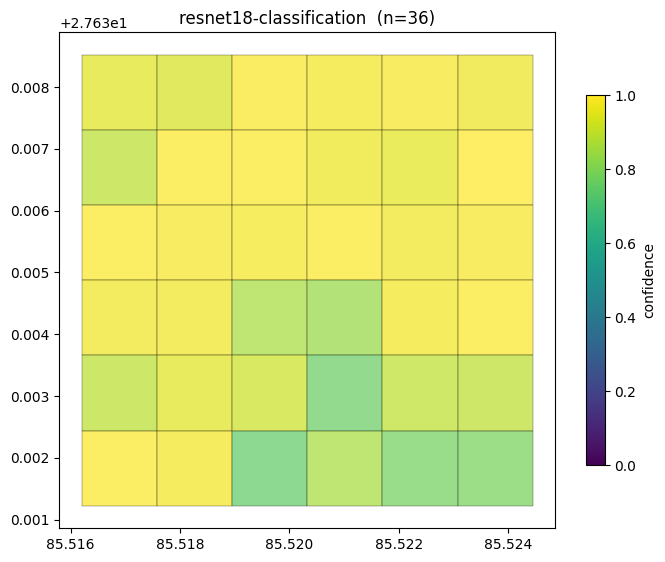

In [38]:
plot(gdf, "resnet18-classification")

## UNet segmentation

In [39]:
gdf = call_predict(
    "08e20666-f8fa-4b8a-8fe8-72661a590fd0",
    collection="local-models",
    params={"confidence_threshold": 0.5, "min_class_value": 1},
)
print(f"features: {len(gdf)}")
gdf.head()

HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/local-models/items/08e20666-f8fa-4b8a-8fe8-72661a590fd0 "HTTP/1.1 200 OK"
HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/base-models/items/unet-segmentation "HTTP/1.1 200 OK"
HTTP Request: POST https://unet-segmentation.predict.fair.krschap.tech/predict "HTTP/1.1 200 OK"
features: 3470


,geometry,class
0,"POLYGON ((85.51683 27.63851, 85.51683 27.6385,...",1
1,"POLYGON ((85.51732 27.63852, 85.51732 27.63852...",1
2,"POLYGON ((85.51745 27.63852, 85.51745 27.63852...",1
3,"POLYGON ((85.51621 27.63852, 85.51621 27.63852...",1
4,"POLYGON ((85.51756 27.63848, 85.51756 27.63847...",1


<Axes: title={'center': 'unet-segmentation  (n=3470)'}>

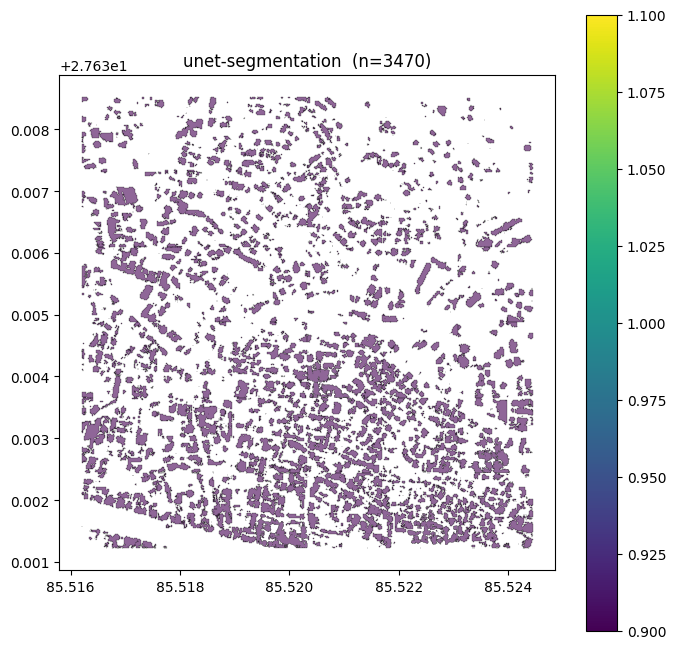

In [40]:
plot(gdf, "unet-segmentation")

## YOLO11n detection

In [ ]:
gdf = call_predict(
    "1e398477-2472-46ea-9286-cd89411e1c32",
    collection="local-models",
    params={"confidence_threshold": 0.5, "iou_threshold": 0.45},
)
print(f"features: {len(gdf)}")
gdf.head()

HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/local-models/items/1e398477-2472-46ea-9286-cd89411e1c32 "HTTP/1.1 200 OK"
HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/base-models/items/yolo11n-detection "HTTP/1.1 200 OK"


<Axes: title={'center': 'yolo11n-detection  (n=547)'}>

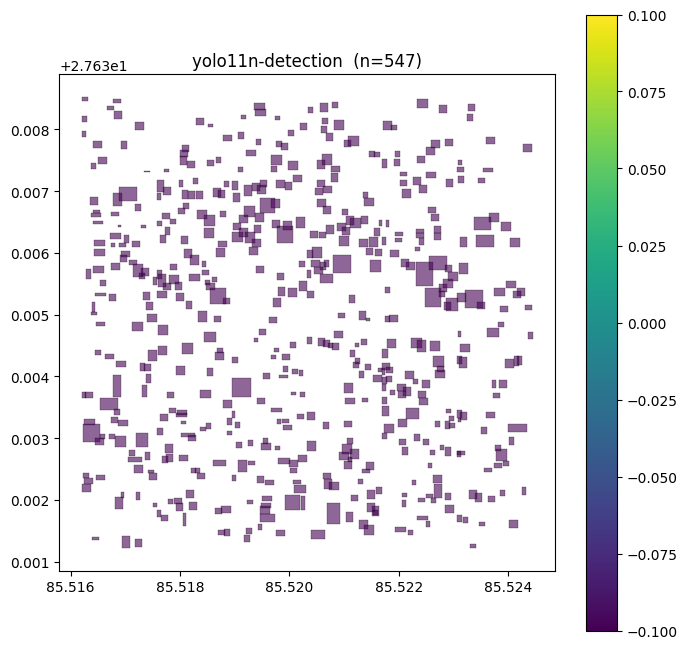

In [ ]:
plot(gdf, "yolo11n-detection")